# Random Forest: TON-IoT Type Prediction and CWE Attack-Family Mapping

copied - edited version of `random_forest_model.ipynb`. 

The model predicts the multiclass TON-IoT `type` target. Its native prediction is then mapped to one of the attack-family labels defined on the `cwe-family-mapping` branch. `label` and `type` are both excluded from the input features to prevent target leakage.

## Steps taken

- Load data
- Remove leakage, identifier-like fields
- Train a multiclass Random Forest to predict `type`
- Evaluate native type predictions with stratified cross-validation and a holdout set
- Map predicted types and probabilities to the CWE notebook's attack families
- Provide a reusable inference helper

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.tree import plot_tree
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

## 1. Load data

In [125]:
RANDOM_STATE = 42
DATA_PATH = "train_test_network.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
required_columns = {"label", "type"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

display(df.head())
display(df["type"].value_counts(dropna=False).rename("count").to_frame())

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


,count
type,
normal,50000
backdoor,20000
ddos,20000
dos,20000
injection,20000
password,20000
scanning,20000
ransomware,20000
xss,20000


## 2. Prepare features

The target is now `type`, not binary `label`. Both target-related columns are removed from `X`. High-cardinality identifiers are also removed because they can encourage memorization and make predictions brittle on new devices or networks.

In [126]:
identifier_columns = [
    "src_ip", "src_port", "dst_ip", "dst_port", "dns_query",
    "ssl_subject", "ssl_issuer", "http_uri", "http_user_agent",
]
excluded_columns = sorted([column for column in identifier_columns if column in df.columns]
    + ["label", "type"]
)

X = df.drop(columns=excluded_columns).replace("-", np.nan).infer_objects()
y = df["type"].astype(str).str.strip().str.lower()

print(f"Excluded columns ({len(excluded_columns)}):", excluded_columns)
print("Initial feature shape:", X.shape)

Excluded columns (11): ['dns_query', 'dst_ip', 'dst_port', 'http_uri', 'http_user_agent', 'label', 'src_ip', 'src_port', 'ssl_issuer', 'ssl_subject', 'type']
Initial feature shape: (211043, 33)


In [127]:
numeric_as_categorical = [
    "dns_qclass", "dns_qtype", "dns_rcode", "http_status_code"
]
numeric_as_categorical = [column for column in numeric_as_categorical if column in X.columns]
X[numeric_as_categorical] = X[numeric_as_categorical].astype("object")

numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = [column for column in X.columns if column not in numeric_cols]

audit = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_pct": X.isna().mean().mul(100),
    "unique": X.nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)
display(audit)

,dtype,missing,missing_pct,unique
http_orig_mime_types,object,211027,99.992419,2
weird_addl,object,210886,99.925608,2
http_resp_mime_types,object,210839,99.903337,9
http_method,object,210756,99.864009,3
http_version,object,210745,99.858797,1
http_trans_depth,object,210740,99.856427,10
weird_notice,object,210687,99.831314,1
weird_name,object,210687,99.831314,10
ssl_cipher,object,210642,99.809991,5
ssl_established,object,210642,99.809991,2


## 3. Split and train the multiclass model

In [128]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
display(y_train.value_counts(normalize=True).rename("train_proportion").to_frame())

Train shape: (158282, 33)
Test shape: (52761, 33)


,train_proportion
type,
normal,0.236919
backdoor,0.094768
injection,0.094768
scanning,0.094768
xss,0.094768
ddos,0.094768
ransomware,0.094768
dos,0.094768
password,0.094768


In [129]:
preprocessor = ColumnTransformer([
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            )),
        ]),
        categorical_cols,
    ),
    (
        "numeric",
        Pipeline([("imputer", SimpleImputer(strategy="median"))]),
        numeric_cols,
    ),
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=18,
        min_samples_split=8,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

## 4. Stratified 5-fold cross-validation

Macro-averaged precision, recall, and F1 give every attack type equal weight, including rare types.

In [130]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
}
cv_results = cross_validate(
    rf_model, X_train, y_train, cv=cv, scoring=cv_scoring, n_jobs=1
)
cv_summary = pd.DataFrame({
    metric: [
        cv_results[f"test_{metric}"].mean(),
        cv_results[f"test_{metric}"].std(),
    ]
    for metric in cv_scoring
}, index=["mean", "std"]).T
display(cv_summary.round(4))

,mean,std
accuracy,0.9760,0.0006
precision_macro,0.9325,0.0012
recall_macro,0.9701,0.0020
f1_macro,0.9453,0.0008


In [131]:
rf_model.fit(X_train, y_train)
y_pred_type = rf_model.predict(X_test)
y_proba_type = rf_model.predict_proba(X_test)
type_classes = rf_model.named_steps["model"].classes_

print(f"Type accuracy: {accuracy_score(y_test, y_pred_type):.4f}")
print(f"Type macro F1: {f1_score(y_test, y_pred_type, average='macro'):.4f}")
print(classification_report(y_test, y_pred_type, digits=4, zero_division=0))

Type accuracy: 0.9773
Type macro F1: 0.9466
              precision    recall  f1-score   support

    backdoor     0.9996    0.9996    0.9996      5000
        ddos     0.9894    0.9674    0.9783      5000
         dos     0.9951    0.9752    0.9851      5000
   injection     0.9799    0.9634    0.9716      5000
        mitm     0.5220    0.9540    0.6748       261
      normal     0.9974    0.9938    0.9956     12500
    password     0.9984    0.9720    0.9850      5000
  ransomware     0.9200    0.9840    0.9509      5000
    scanning     0.9874    0.9906    0.9890      5000
         xss     0.9469    0.9264    0.9365      5000

    accuracy                         0.9773     52761
   macro avg     0.9336    0.9726    0.9466     52761
weighted avg     0.9796    0.9773    0.9780     52761



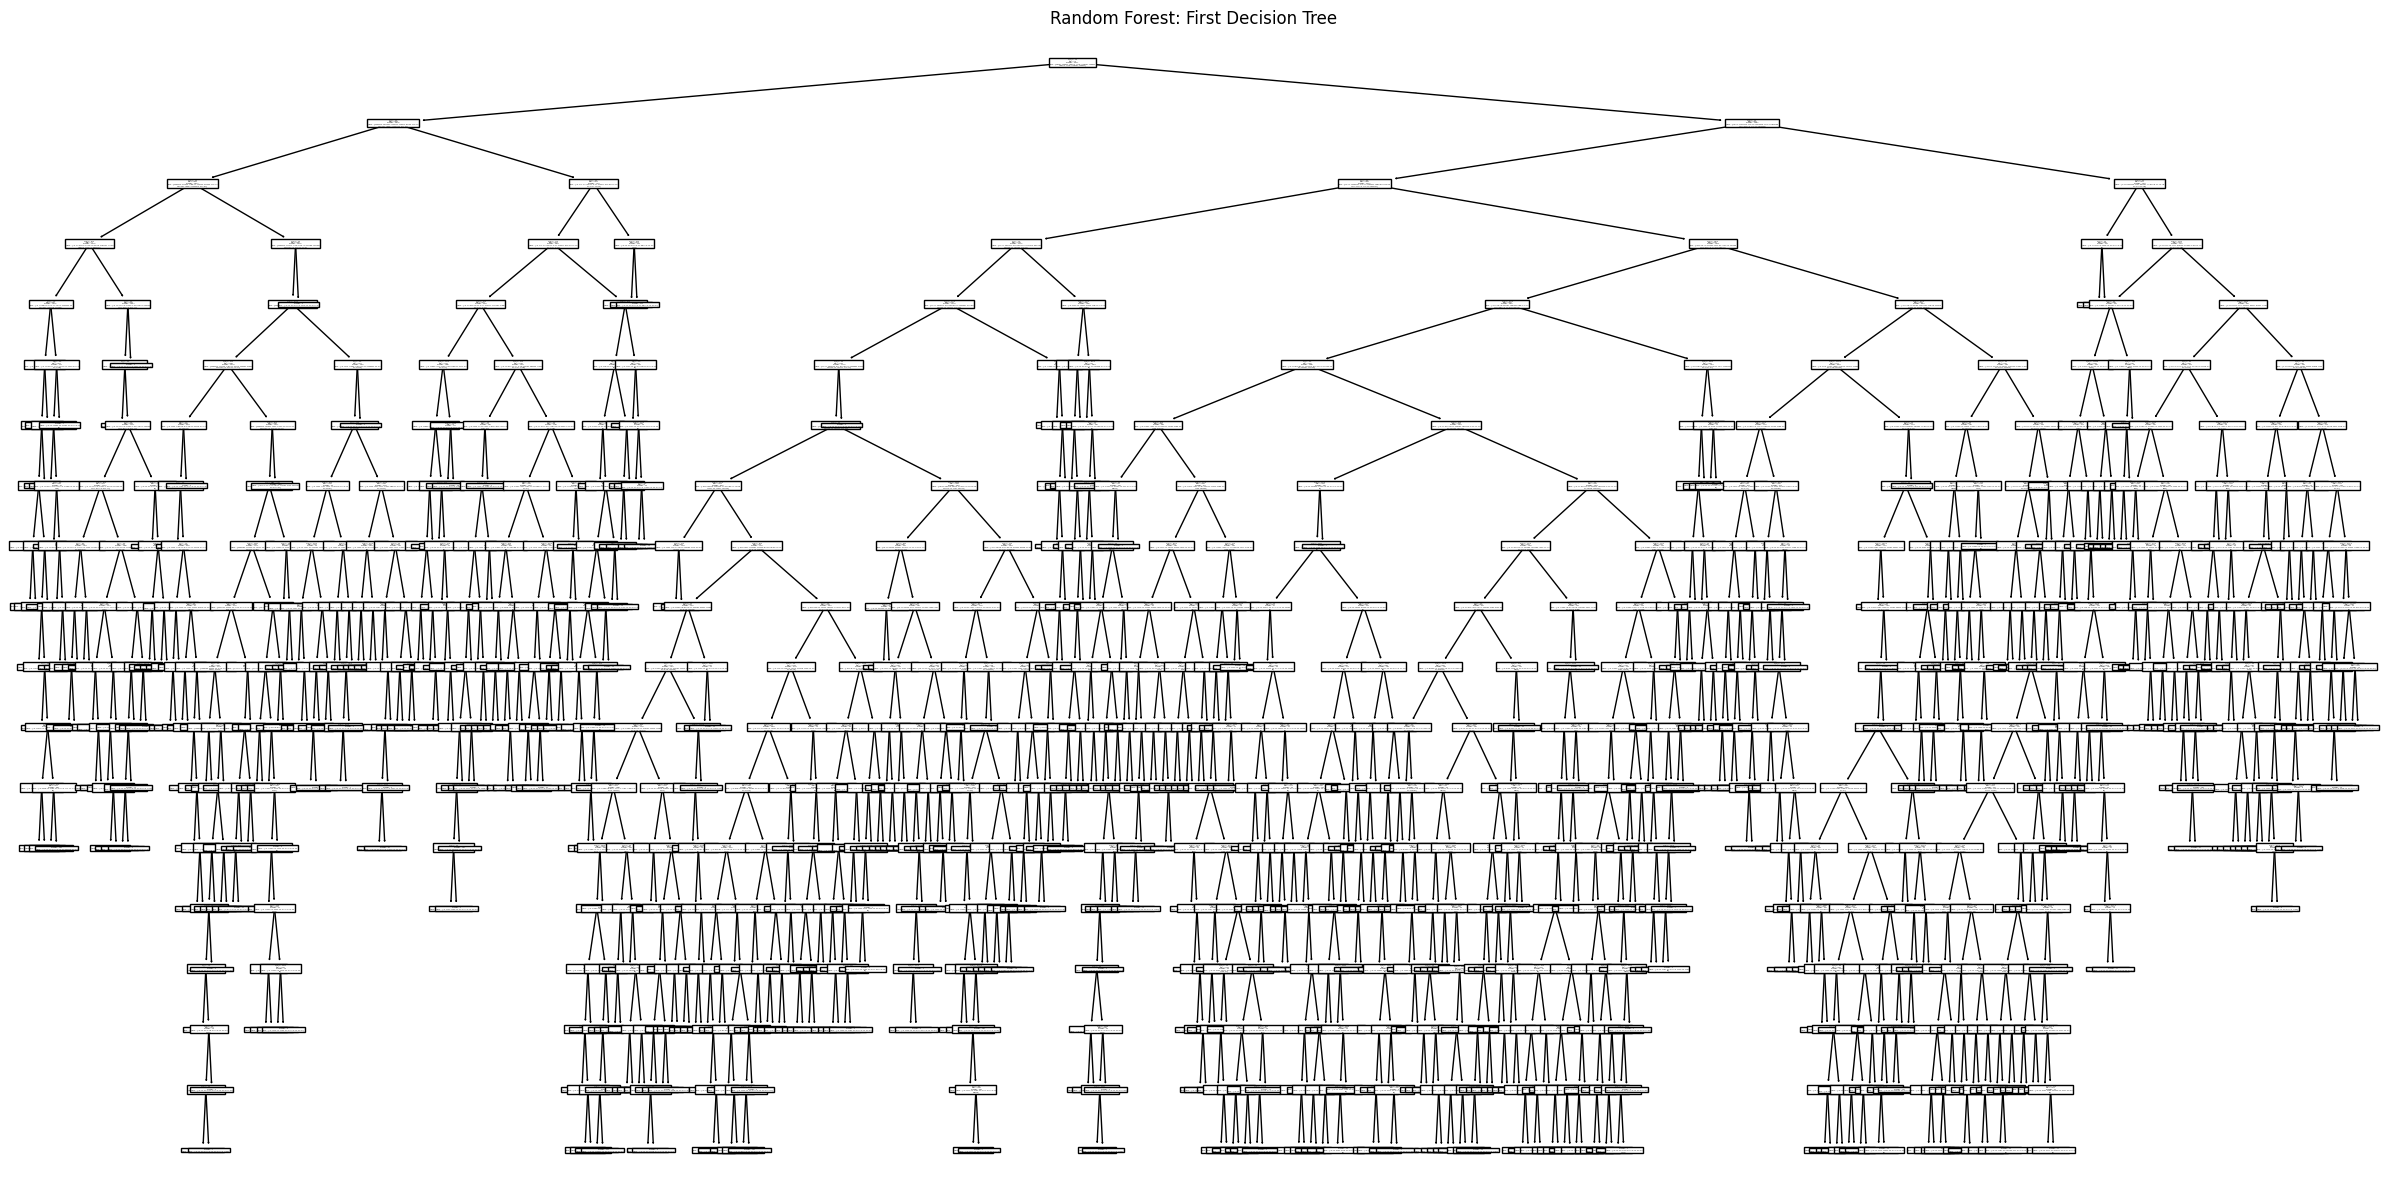

In [132]:
forest = rf_model.named_steps["model"]
tree = forest.estimators_[0]

# ColumnTransformer outputs categorical columns first, then numeric columns
feature_names = categorical_cols + numeric_cols
class_names = [str(label) for label in forest.classes_]

plt.figure(figsize=(24, 12))

plot_tree(
    tree
)

plt.title("Random Forest: First Decision Tree")
plt.tight_layout()
plt.show()

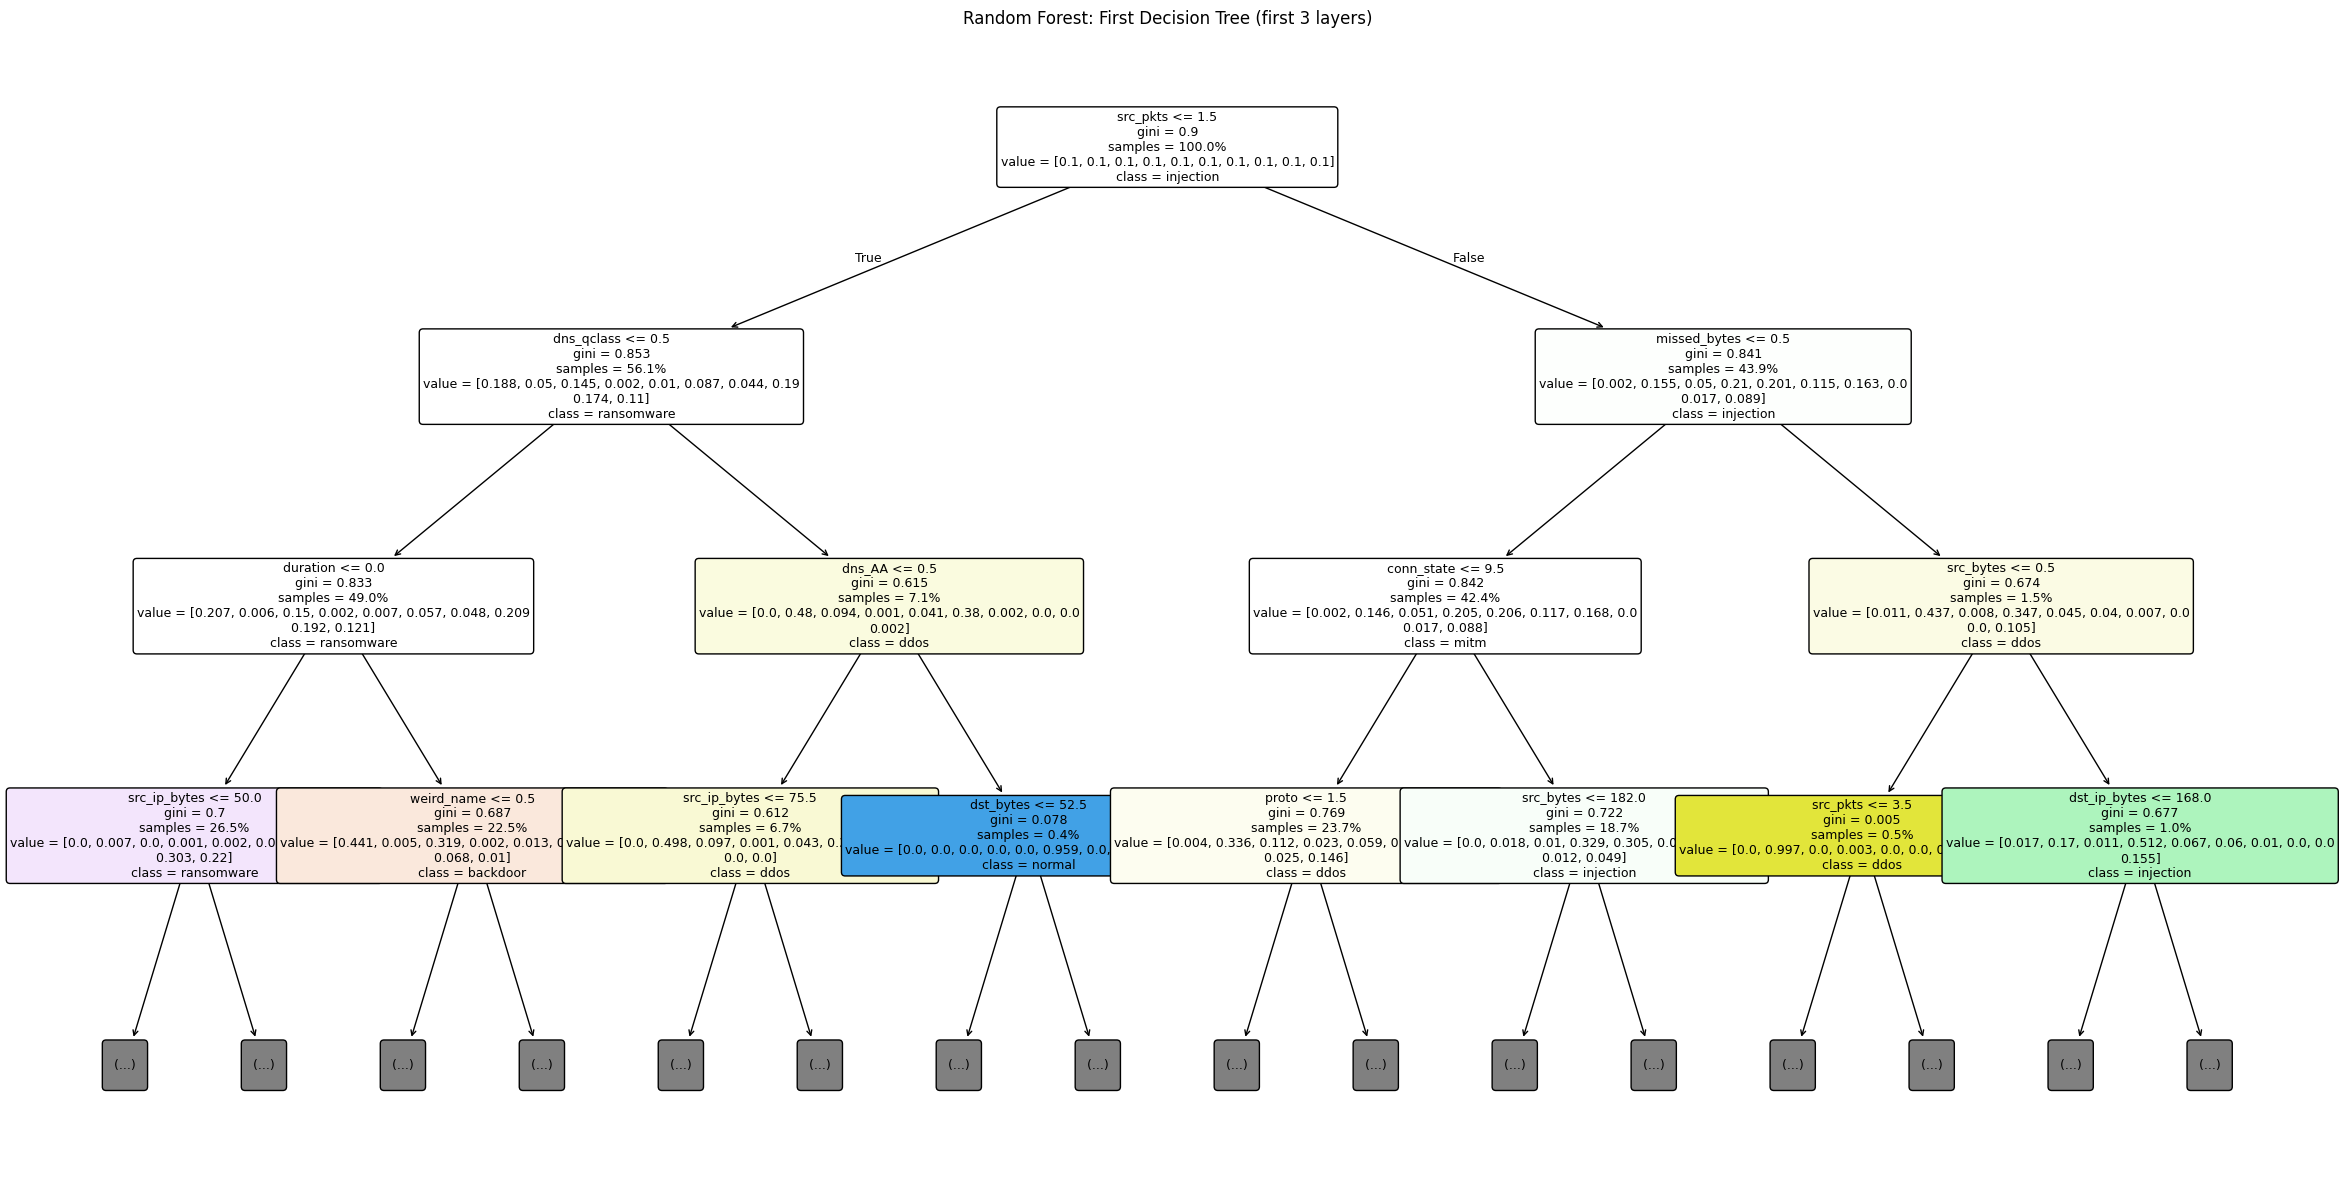

In [133]:
plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
    proportion=True,
    precision=3
)

plt.title("Random Forest: First Decision Tree (first 3 layers)")
plt.tight_layout()
plt.show()

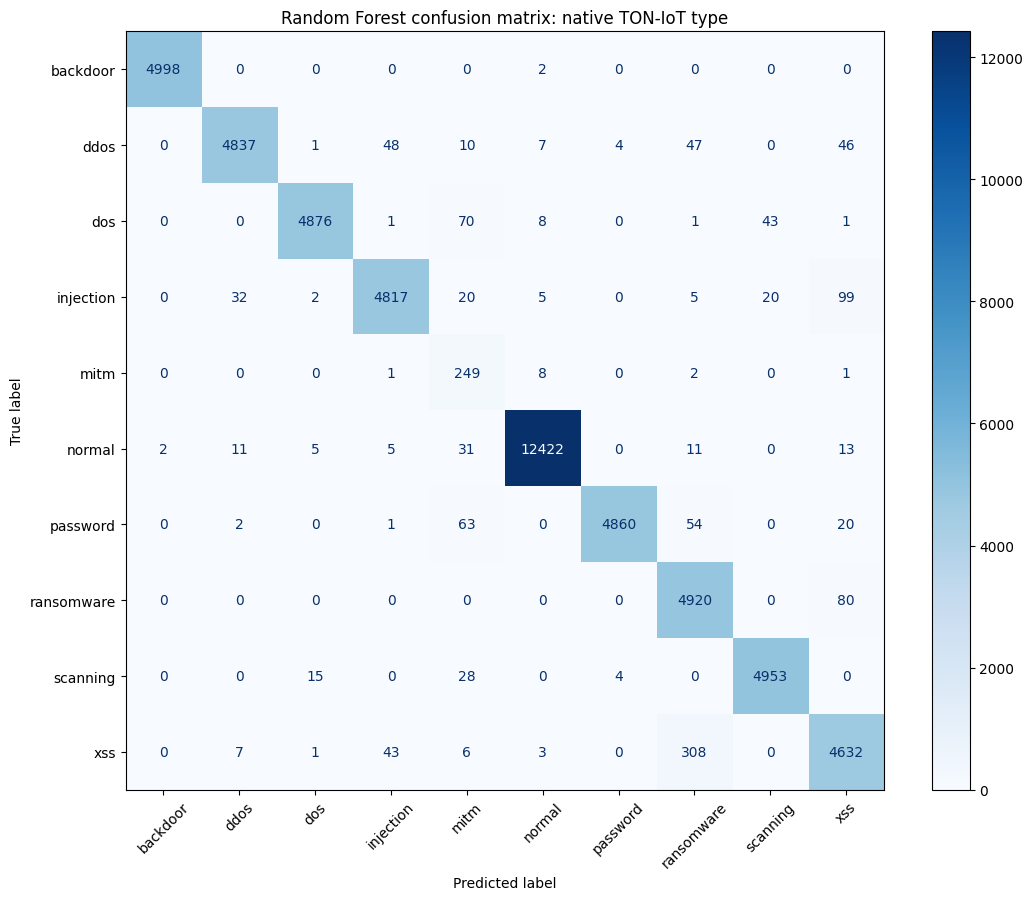

In [134]:
fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_type, labels=type_classes, cmap="Blues",
    xticks_rotation=45, values_format="d", ax=ax,
)
ax.set_title("Random Forest confusion matrix: native TON-IoT type")
plt.tight_layout()
plt.show()

## 5. Map predicted types to the `cwe-family-mapping` families

The family vocabulary below is copied from `cwe_family_mapping.ipynb` on `origin/cwe-family-mapping`. The mapping is deliberately conservative. Native types without a defensible equivalent in that CWE-oriented vocabulary use its existing `Other` bucket. A `normal` prediction also maps to `Other`, but remains distinguishable through `predicted_type` and `is_attack=False`.

In [135]:
CWE_ATTACK_FAMILIES = (
    "Injection",
    "XSS",
    "Memory Corruption",
    "Info Disclosure",
    "CSRF",
    "Path Traversal",
    "Authentication & Access Control",
    "File Handling",
    "Denial of Service",
    "Cryptographic Issues",
    "Deserialization",
    "Race Condition",
    "Other",
)

TYPE_TO_ATTACK_FAMILY = {
    "normal": "Other",
    "backdoor": "Other",
    "ddos": "Denial of Service",
    "dos": "Denial of Service",
    "injection": "Injection",
    "mitm": "Cryptographic Issues",
    "password": "Authentication & Access Control",
    "ransomware": "Other",
    "scanning": "Other",
    "xss": "XSS",
}

assert set(TYPE_TO_ATTACK_FAMILY.values()).issubset(CWE_ATTACK_FAMILIES)

def map_type_to_attack_family(type_label):
    normalized = str(type_label).strip().lower()
    return TYPE_TO_ATTACK_FAMILY.get(normalized, "Other")

unlisted_model_types = sorted(set(type_classes) - set(TYPE_TO_ATTACK_FAMILY))
if unlisted_model_types:
    print("Unlisted native types will map to Other:", unlisted_model_types)

display(pd.Series(TYPE_TO_ATTACK_FAMILY, name="attack_family").rename_axis("type").to_frame())

,attack_family
type,
normal,Other
backdoor,Other
ddos,Denial of Service
dos,Denial of Service
injection,Injection
mitm,Cryptographic Issues
password,Authentication & Access Control
ransomware,Other
scanning,Other


In [136]:
y_test_family = y_test.map(map_type_to_attack_family)
y_pred_family = pd.Series(y_pred_type, index=y_test.index).map(map_type_to_attack_family)

prediction_results = pd.DataFrame({
    "actual_type": y_test,
    "predicted_type": y_pred_type,
    "actual_attack_family": y_test_family,
    "predicted_attack_family": y_pred_family,
    "is_attack": pd.Series(y_pred_type, index=y_test.index).ne("normal"),
})
display(prediction_results.head(20))

print(f"Mapped-family accuracy: {accuracy_score(y_test_family, y_pred_family):.4f}")
print(f"Mapped-family macro F1: {f1_score(y_test_family, y_pred_family, average='macro'):.4f}")
print(classification_report(
    y_test_family, y_pred_family, digits=4, zero_division=0
))

,actual_type,predicted_type,actual_attack_family,predicted_attack_family,is_attack
54646,dos,dos,Denial of Service,Denial of Service,True
192049,xss,xss,XSS,XSS,True
173589,scanning,scanning,Other,Other,True
63070,injection,injection,Injection,Injection,True
191694,xss,xss,XSS,XSS,True
57059,dos,dos,Denial of Service,Denial of Service,True
32018,ddos,ddos,Denial of Service,Denial of Service,True
148233,password,password,Authentication & Access Control,Authentication & Access Control,True
113726,normal,normal,Other,Other,False
101813,normal,normal,Other,Other,False


Mapped-family accuracy: 0.9776
Mapped-family macro F1: 0.9228
                                 precision    recall  f1-score   support

Authentication & Access Control     0.9984    0.9720    0.9850      5000
           Cryptographic Issues     0.5220    0.9540    0.6748       261
              Denial of Service     0.9923    0.9714    0.9818     10000
                      Injection     0.9799    0.9634    0.9716      5000
                          Other     0.9816    0.9930    0.9873     27500
                            XSS     0.9469    0.9264    0.9365      5000

                       accuracy                         0.9776     52761
                      macro avg     0.9035    0.9634    0.9228     52761
                   weighted avg     0.9795    0.9776    0.9782     52761



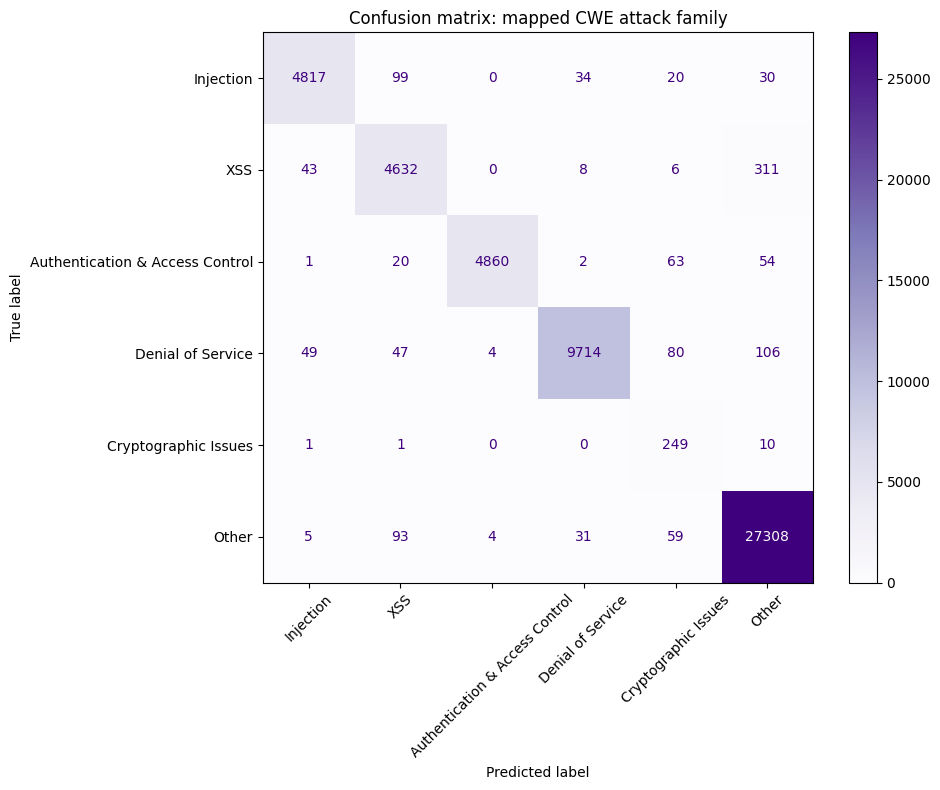

In [137]:
family_labels_present = [
    family for family in CWE_ATTACK_FAMILIES
    if family in set(y_test_family).union(y_pred_family)
]
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_family, y_pred_family, labels=family_labels_present,
    cmap="Purples", xticks_rotation=45, values_format="d", ax=ax,
)
ax.set_title("Confusion matrix: mapped CWE attack family")
plt.tight_layout()
plt.show()

## 6. Reusable inference helper

This helper returns the native type prediction, its mapped CWE family, an explicit attack flag, and both native-type and mapped-family confidence values. When multiple native types map to one family (for example, `dos` and `ddos`), their probabilities are added.

In [138]:
def aggregate_family_probabilities(type_probabilities, type_labels):
    family_probabilities = {family: 0.0 for family in CWE_ATTACK_FAMILIES}
    for probability, type_label in zip(type_probabilities, type_labels):
        family = map_type_to_attack_family(type_label)
        family_probabilities[family] += float(probability)
    return family_probabilities


def predict_type_and_attack_family(rows):
    """Predict native TON-IoT type and map it to the CWE family vocabulary."""
    predicted_types = rf_model.predict(rows)
    type_probabilities = rf_model.predict_proba(rows)
    normal_positions = np.flatnonzero(type_classes == "normal")
    normal_position = int(normal_positions[0]) if len(normal_positions) else None
    results = []

    for predicted_type, probabilities in zip(predicted_types, type_probabilities):
        family_probabilities = aggregate_family_probabilities(probabilities, type_classes)
        predicted_family = map_type_to_attack_family(predicted_type)
        normal_probability = (
            float(probabilities[normal_position]) if normal_position is not None else 0.0
        )
        results.append({
            "predicted_type": predicted_type,
            "attack_family": predicted_family,
            "is_attack": predicted_type != "normal",
            "attack_probability": 1.0 - normal_probability,
            "type_confidence": float(np.max(probabilities)),
            "family_confidence": family_probabilities[predicted_family],
            "family_probabilities": family_probabilities,
        })

    return pd.DataFrame(results, index=rows.index)


inference_example = predict_type_and_attack_family(X_test.head(10))
display(inference_example)

,predicted_type,attack_family,is_attack,attack_probability,type_confidence,family_confidence,family_probabilities
54646,dos,Denial of Service,True,0.994157,0.888243,0.924939,"{'Injection': 0.014965964087367141, 'XSS': 0.0..."
192049,xss,XSS,True,0.978250,0.876661,0.876661,"{'Injection': 0.0182433022474718, 'XSS': 0.876..."
173589,scanning,Other,True,0.996361,0.984088,0.995788,"{'Injection': 2.399812113650331e-05, 'XSS': 0...."
63070,injection,Injection,True,0.999312,0.986497,0.986497,"{'Injection': 0.9864968468849612, 'XSS': 0.002..."
191694,xss,XSS,True,0.994819,0.933239,0.933239,"{'Injection': 0.01563078435819305, 'XSS': 0.93..."
57059,dos,Denial of Service,True,0.998539,0.945867,0.945974,"{'Injection': 8.079881652990158e-05, 'XSS': 0...."
32018,ddos,Denial of Service,True,0.997126,0.993023,0.995029,"{'Injection': 0.00015882577949498267, 'XSS': 5..."
148233,password,Authentication & Access Control,True,0.999446,0.970520,0.970520,"{'Injection': 0.02440669269633512, 'XSS': 0.00..."
113726,normal,Other,False,0.012702,0.987298,0.987586,"{'Injection': 0.0011386132300967, 'XSS': 0.000..."
101813,normal,Other,False,0.001353,0.998647,0.998652,"{'Injection': 1.1867086599249856e-05, 'XSS': 4..."


## 7. Export the complete pipeline as a `.pkl`

The exported object is still the fitted scikit-learn `Pipeline`, so the repository's existing `joblib.load(...)` inference path can use it directly. Deployment metadata is attached to that pipeline before serialization, keeping the model, preprocessing, required feature schema, class names, and CWE-family mapping together in one trusted artifact.

In [139]:
from pathlib import Path
import platform
import joblib
import sklearn

EXPORT_PATH = Path("exported_model/type_random_forest.pkl")
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Keep the object pipeline-compatible while embedding its deployment contract.
rf_model.artifact_version_ = "1.0"
rf_model.target_ = "type"
rf_model.normal_type_ = "normal"
rf_model.input_features_ = list(X.columns)
rf_model.input_dtypes_ = {column: str(dtype) for column, dtype in X.dtypes.items()}
rf_model.categorical_features_ = list(categorical_cols)
rf_model.numeric_features_ = list(numeric_cols)
rf_model.excluded_columns_ = list(excluded_columns)
rf_model.native_type_classes_ = [str(value) for value in type_classes]
rf_model.type_to_attack_family_ = dict(TYPE_TO_ATTACK_FAMILY)
rf_model.cwe_attack_families_ = list(CWE_ATTACK_FAMILIES)
rf_model.holdout_metrics_ = {
    "type_accuracy": float(accuracy_score(y_test, y_pred_type)),
    "type_macro_f1": float(f1_score(y_test, y_pred_type, average="macro")),
    "family_accuracy": float(accuracy_score(y_test_family, y_pred_family)),
    "family_macro_f1": float(f1_score(y_test_family, y_pred_family, average="macro")),
}
rf_model.training_versions_ = {
    "python": platform.python_version(),
    "scikit_learn": sklearn.__version__,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "joblib": joblib.__version__,
}

joblib.dump(rf_model, EXPORT_PATH)
print(f"Exported complete pipeline to: {EXPORT_PATH.resolve()}")

Exported complete pipeline to: D:\CODING\codes\TON_loT_network\exported_model\type_random_forest.pkl


In [140]:
# Reload and smoke-test the exact artifact that will be deployed.
exported_model = joblib.load(EXPORT_PATH)
exported_example = exported_model.predict(X_test.head(5))

assert list(exported_model.input_features_) == list(X.columns)
assert exported_model.type_to_attack_family_ == TYPE_TO_ATTACK_FAMILY
assert np.array_equal(exported_example, rf_model.predict(X_test.head(5)))

display(pd.DataFrame({
    "predicted_type": exported_example,
    "attack_family": [
        exported_model.type_to_attack_family_.get(str(value).lower(), "Other")
        for value in exported_example
    ],
}, index=X_test.head(5).index))
print("Reload validation passed.")

,predicted_type,attack_family
54646,dos,Denial of Service
192049,xss,XSS
173589,scanning,Other
63070,injection,Injection
191694,xss,XSS


Reload validation passed.


### Pipeline input

Point `network.model_path` at `exported_model/ton_iot_type_random_forest.pkl`. Supply every field in `exported_model.input_features_`; the serialized preprocessing steps handle missing values and categorical encoding. Only load this artifact from a trusted source because pickle-based formats can execute code during loading.

## 8. Feature-meaning check

Permutation importance checks whether the multiclass model relies on meaningful behavior and protocol features. Macro F1 is used because this is no longer a binary classifier.

In [141]:
perm_importance = permutation_importance(
    rf_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
    scoring="f1_macro", n_jobs=1,
)
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean": perm_importance.importances_mean,
    "std": perm_importance.importances_std,
}).sort_values("mean", ascending=False).reset_index(drop=True)

display(importance_df.head(20).round(4))

,feature,mean,std
0,src_ip_bytes,0.2956,0.0007
1,conn_state,0.2515,0.0011
2,src_bytes,0.1100,0.0013
3,duration,0.0678,0.0010
4,src_pkts,0.0624,0.0007
5,proto,0.0326,0.0006
6,dst_ip_bytes,0.0206,0.0004
7,dst_bytes,0.0085,0.0002
8,missed_bytes,0.0027,0.0001
9,dst_pkts,0.0012,0.0005


## Side notes

Use `predicted_type` when the native TON-IoT class matters. Use `attack_family` when joining or comparing results with the CWE-family notebook. 

`Other` is not necessary an an attack: consult `is_attack`, because the CWE family list has no benign class and therefore `normal` is represented as `Other` only at the mapping layer.

In [142]:
from pathlib import Path
import json
import platform

import joblib
import sklearn

EXPORT_DIR = Path("exported_model")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = EXPORT_DIR / "type_random_forest.joblib"
METADATA_PATH = EXPORT_DIR / "type_random_forest.metrics.json"
MAPPING_PATH = EXPORT_DIR / "type_to_cwe_family.json"

# Includes the fitted preprocessor and Random Forest.
joblib.dump(rf_model, MODEL_PATH)

metadata = {
    "artifact_version": "1.0",
    "target": "type",
    "classes": [str(value) for value in type_classes],
    "input_features": list(X.columns),
    "input_dtypes": {
        column: str(dtype)
        for column, dtype in X.dtypes.items()
    },
    "categorical_features": categorical_cols,
    "numeric_features": numeric_cols,
    "excluded_columns": excluded_columns,
    "normal_type": "normal",
    "random_state": RANDOM_STATE,
    "holdout_metrics": {
        "type_accuracy": float(
            accuracy_score(y_test, y_pred_type)
        ),
        "type_macro_f1": float(
            f1_score(y_test, y_pred_type, average="macro")
        ),
        "family_accuracy": float(
            accuracy_score(y_test_family, y_pred_family)
        ),
        "family_macro_f1": float(
            f1_score(y_test_family, y_pred_family, average="macro")
        ),
    },
    "versions": {
        "python": platform.python_version(),
        "scikit_learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}

with METADATA_PATH.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)
    file.write("\n")

mapping_artifact = {
    "attack_families": list(CWE_ATTACK_FAMILIES),
    "type_to_attack_family": TYPE_TO_ATTACK_FAMILY,
    "fallback_family": "Other",
    "normal_type": "normal",
}

with MAPPING_PATH.open("w", encoding="utf-8") as file:
    json.dump(mapping_artifact, file, indent=2)
    file.write("\n")

print("Exported:")
print(MODEL_PATH)
print(METADATA_PATH)
print(MAPPING_PATH)

Exported:
exported_model\type_random_forest.joblib
exported_model\type_random_forest.metrics.json
exported_model\type_to_cwe_family.json


## 9. Export a presentation-ready evaluation image

This cell exports the headline metrics, normalized confusion matrix, and per-class F1 scores as three separate high-resolution PNG files. Rerun it after retraining to refresh the images.

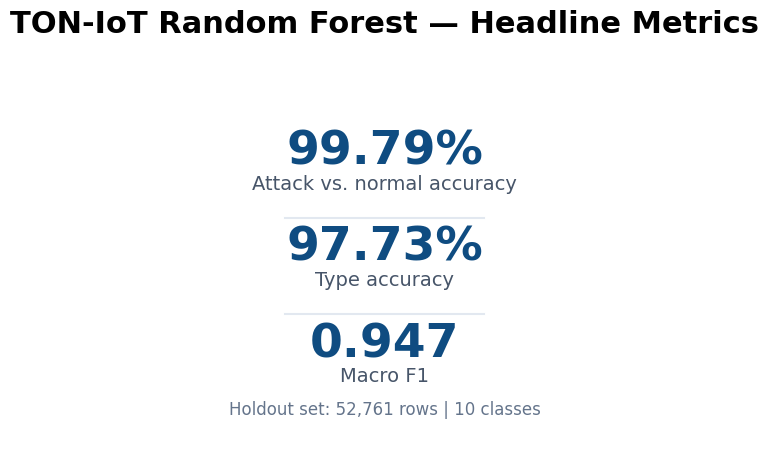

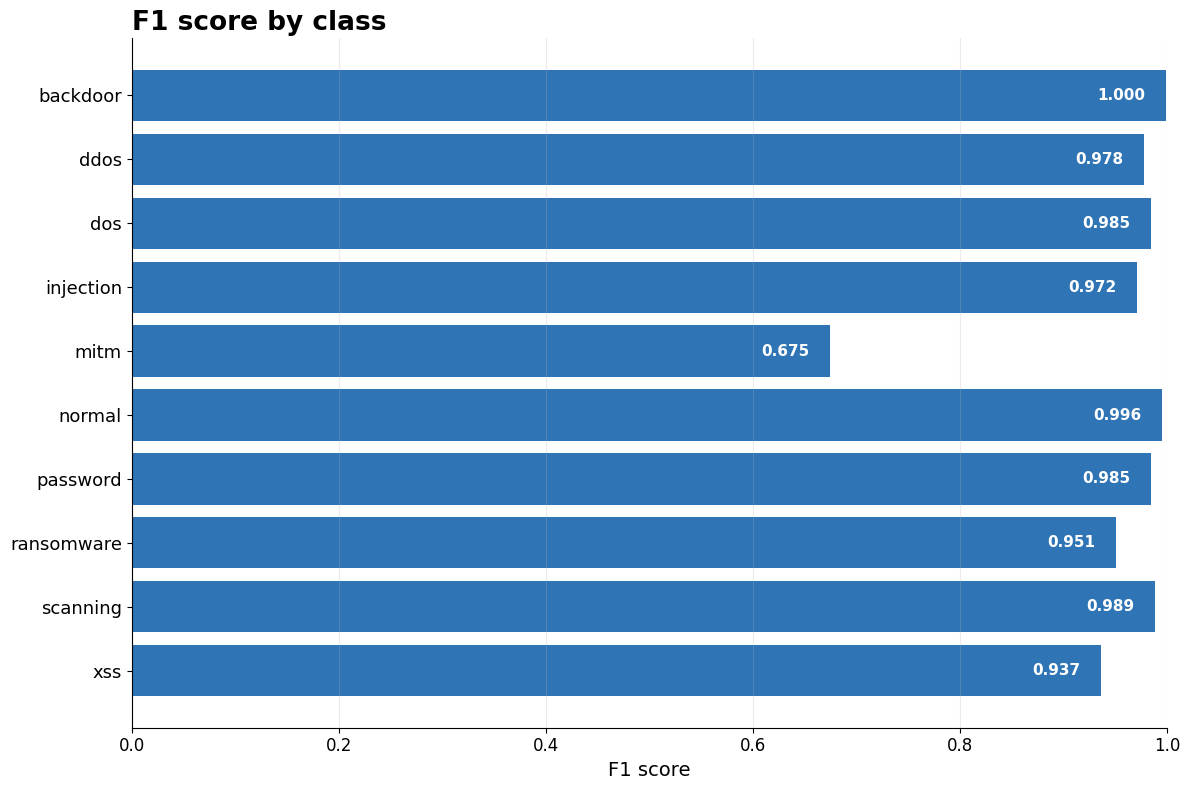

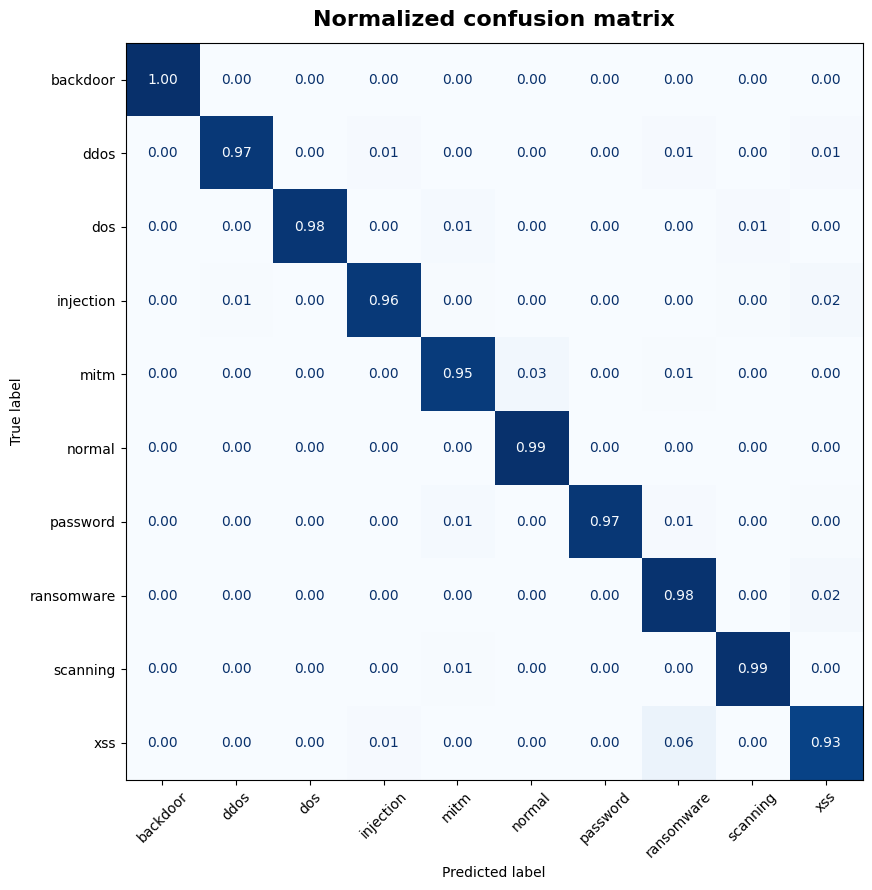

Saved evaluation graphics:
D:\CODING\codes\TON_loT_network\presentation_assets\random_forest_metrics.png
D:\CODING\codes\TON_loT_network\presentation_assets\random_forest_f1_by_class.png
D:\CODING\codes\TON_loT_network\presentation_assets\random_forest_confusion_matrix.png


In [156]:
from pathlib import Path

from sklearn.metrics import confusion_matrix

evaluation_accuracy = accuracy_score(y_test, y_pred_type)
evaluation_macro_f1 = f1_score(
    y_test, y_pred_type, average="macro", zero_division=0
)
attack_truth = y_test.ne("normal")
attack_prediction = pd.Series(
    y_pred_type, index=y_test.index
).ne("normal")
attack_accuracy = accuracy_score(attack_truth, attack_prediction)

normalized_cm = confusion_matrix(
    y_test, y_pred_type, labels=type_classes, normalize="true"
)
class_f1 = f1_score(
    y_test,
    y_pred_type,
    labels=type_classes,
    average=None,
    zero_division=0,
)

output_dir = Path("presentation_assets")
output_dir.mkdir(parents=True, exist_ok=True)

# 1. Headline metrics
metrics_fig, metrics_ax = plt.subplots(figsize=(4, 5), facecolor="white")
metrics_ax.axis("off")
metrics_ax.set_title(
    "TON-IoT Random Forest — Headline Metrics",
    fontsize=22, fontweight="bold", pad=20
)
metric_rows = [
    ("Attack vs. normal accuracy", f"{attack_accuracy:.2%}"),
    ("Type accuracy", f"{evaluation_accuracy:.2%}"),
    ("Macro F1", f"{evaluation_macro_f1:.3f}"),
]
for row, (label, value) in enumerate(metric_rows):
    y_position = 0.73 - row * 0.25
    metrics_ax.text(
        0.5, y_position, value, ha="center", fontsize=34,
        fontweight="bold", color="#0F4C81"
    )
    metrics_ax.text(
        0.5, y_position - 0.065, label, ha="center",
        fontsize=14, color="#475569"
    )
    if row < len(metric_rows) - 1:
        metrics_ax.axhline(
            y_position - 0.14, xmin=0.18, xmax=0.82,
            color="#E2E8F0", linewidth=1.5
        )
metrics_ax.text(
    0.5, 0.08, f"Holdout set: {len(y_test):,} rows | {len(type_classes)} classes",
    ha="center", fontsize=12, color="#64748B"
)
metrics_path = output_dir / "random_forest_metrics.png"
metrics_fig.savefig(metrics_path, dpi=220, bbox_inches="tight", facecolor="white")

# 2. F1 score by class
f1_fig, f1_ax = plt.subplots(figsize=(12, 8), facecolor="white")
positions = np.arange(len(type_classes))
f1_ax.barh(positions, class_f1, color="#2F75B5")
f1_ax.set_yticks(positions, labels=type_classes, fontsize=13)
f1_ax.invert_yaxis()
f1_ax.set_xlim(0, 1.0)
f1_ax.set_xlabel("F1 score", fontsize=14)
f1_ax.set_title("F1 score by class", loc="left", fontsize=19, fontweight="bold")
f1_ax.tick_params(axis="x", labelsize=12)
f1_ax.grid(axis="x", alpha=0.25)
for position, score in zip(positions, class_f1):
    f1_ax.text(
        max(score - 0.02, 0.02), position, f"{score:.3f}",
        ha="right", va="center", fontsize=11,
        fontweight="bold", color="white"
    )
for spine in ("top", "right"):
    f1_ax.spines[spine].set_visible(False)
f1_fig.tight_layout()
f1_path = output_dir / "random_forest_f1_by_class.png"
f1_fig.savefig(f1_path, dpi=220, bbox_inches="tight", facecolor="white")

# 3. Normalized confusion matrix
cm_fig, cm_ax = plt.subplots(figsize=(11, 9), facecolor="white")
ConfusionMatrixDisplay(
    confusion_matrix=normalized_cm, display_labels=type_classes
).plot(
    ax=cm_ax, cmap="Blues", values_format=".2f", colorbar=False
)
cm_ax.set_title(
    "Normalized confusion matrix", fontsize=16, fontweight="bold", pad=12
)
cm_ax.tick_params(axis="x", rotation=45)

cm_fig.tight_layout()
cm_path = output_dir / "random_forest_confusion_matrix.png"
cm_fig.savefig(cm_path, dpi=220, bbox_inches="tight", facecolor="white")

plt.show()
print("Saved evaluation graphics:")
print(metrics_path.resolve())
print(f1_path.resolve())
print(cm_path.resolve())